In [1]:
import sys
new_path = '/home/eltons-pc/Code/federated-sc-depth/src'
sys.path.append(new_path)

In [2]:
DDAD_CENTRALIZED_TRAINING_DIRPATH = '/home/eltons-pc/Logs/centralized_sc_depth/ddad/'
DDAD_CENTRALIZED_TRAINING_ID = '10_06_2023' # 100 epochs with 1000 train batches and all val batches

FEDERATED_TRAINING_ID_SEARCH_RANGE_4 = '03_11_2024_00:29:15' # DISTRIBUTION = KITTI; TOTAL PARTICIPANTS = 12 ; PARTICIPANTS PER ROUND = 4 ; LOCAL EPOCHS = 3; SEARCH RANGE = 4; MAX LOCAL BATCHES TRAIN = 1000; MAX LOCAL BATCHES VAL = -1; MAX_ROUNDS = 36 ; 
FEDERATED_TRAINING_ID_SEARCH_RANGE_6 = '09_10_2023_22:04:30' # DISTRIBUTION = KITTI; TOTAL PARTICIPANTS = 12 ; PARTICIPANTS PER ROUND = 4 ; LOCAL EPOCHS = 3; SEARCH RANGE = 6; MAX LOCAL BATCHES TRAIN = 1000; MAX LOCAL BATCHES VAL = -1; MAX_ROUNDS = 36 ; 
FEDERATED_TRAINING_ID_SEARCH_RANGE_8 = '11_11_2024_17:54:25' # DISTRIBUTION = KITTI; TOTAL PARTICIPANTS = 12 ; PARTICIPANTS PER ROUND = 4 ; LOCAL EPOCHS = 3; SEARCH RANGE = 8; MAX LOCAL BATCHES TRAIN = 1000; MAX LOCAL BATCHES VAL = -1; MAX_ROUNDS = 36 ; 
FEDERATED_TRAINING_ID_SEARCH_RANGE_10 = '13_11_2024_22:59:48' # DISTRIBUTION = KITTI; TOTAL PARTICIPANTS = 12 ; PARTICIPANTS PER ROUND = 4 ; LOCAL EPOCHS = 3; SEARCH RANGE = 10; MAX LOCAL BATCHES TRAIN = 1000; MAX LOCAL BATCHES VAL = -1; MAX_ROUNDS = 36 ; 
FEDERATED_TRAINING_ID_SEARCH_RANGE_12 = '03_11_2024_22:10:00' # DISTRIBUTION = KITTI; TOTAL PARTICIPANTS = 12 ; PARTICIPANTS PER ROUND = 4 ; LOCAL EPOCHS = 3; SEARCH RANGE = 12; MAX LOCAL BATCHES TRAIN = 1000; MAX LOCAL BATCHES VAL = -1; MAX_ROUNDS = 36 ;
 

DDAD_FEDERATED_TRAINING_DIRPATH = '/home/eltons-pc/Logs/federated-sc-depth/'
DDAD_TRAINING_IDS = [
    FEDERATED_TRAINING_ID_SEARCH_RANGE_4, FEDERATED_TRAINING_ID_SEARCH_RANGE_6, 
    FEDERATED_TRAINING_ID_SEARCH_RANGE_8, FEDERATED_TRAINING_ID_SEARCH_RANGE_10,
    FEDERATED_TRAINING_ID_SEARCH_RANGE_12
]
DDAD_TRAINING_LABELS = [
    "&#936;=4 - DDAD",
    "&#936;=6 - DDAD",
    "&#936;=8 - DDAD",
    "&#936;=10 - DDAD",
    "&#936;=12 - DDAD"
]
DDAD_TRAINING_CENTRALIZED = [
    False,
    False,
    False,
    False,
    False
]
DDAD_SMART_GLOBAL_UPDATE = [
    True,
    True,
    True,
    True,
    True
]
DDAD_ROUND_CAP = 12
DDAD_NUM_CLIENTS = 12
#MODEL_SIZE_MB = 111.417 # estimated by pytorch
DDAD_MODEL_SIZE_MB = 106.32868194580078 # estimated in code
DDAD_NUM_VAL_SAMPLES = 3950
DDAD_BATCH_SIZE = 4

In [3]:
import os
from util import get_dir_size
import pandas as pd
DDAD_TRAIN_DATASET_DIR = '/home/eltons-pc/Datasets/ddad/training'
DDAD_FORMATS = ['jpg', 'png']
ddad_total_files, ddad_total_size_gb, ddad_filtered_files, ddad_filtered_size_gb = get_dir_size(DDAD_TRAIN_DATASET_DIR, DDAD_FORMATS)
ddad_df_columns = ['Total Files', 'Total Size (GB)', f'{DDAD_FORMATS} Files', f'{DDAD_FORMATS} Size (GB)']
ddad_df_rows = [ddad_total_files, ddad_total_size_gb, ddad_filtered_files, ddad_filtered_size_gb]
ddad_df = pd.DataFrame({'': ddad_df_columns, 'Value': ddad_df_rows})
ddad_df

,,Value
0,Total Files,49879.00
1,Total Size (GB),4.77
2,"['jpg', 'png'] Files",33118.00
3,"['jpg', 'png'] Size (GB)",4.56


In [4]:
show_legend = True
fig_config = dict(x_tick_size=25, y_tick_size=25, legend_size=25, trace_size = 6, show_legend = show_legend, marker_size=18)

In [5]:
from util import get_federated_training_charts, get_centralized_training_charts, standardize_fig
import plotly.graph_objects as go

test_loss_figures = []
communication_cost_upper_bound_figures = []
communication_cost_lower_bound_figures = []
num_inferences_figures = []
num_averagings_figures = []
test_loss_by_communication_upper_bound_cost_figures = []
test_loss_by_communication_lower_bound_cost_figures = []

In [6]:
for i in range(len(DDAD_TRAINING_IDS)):
    print(DDAD_TRAINING_LABELS[i])
    if DDAD_TRAINING_CENTRALIZED[i]:
        ddad_test_loss_by_training_step_fig, ddad_communication_cost_by_training_step, ddad_test_loss_by_communication_cost_fig, ddad_num_inferences_by_training_step_fig = get_centralized_training_charts(
            DDAD_CENTRALIZED_TRAINING_DIRPATH, DDAD_TRAINING_IDS[i], DDAD_TRAINING_LABELS[i], ddad_filtered_size_gb, 1, DDAD_MODEL_SIZE_MB, DDAD_NUM_CLIENTS, DDAD_NUM_VAL_SAMPLES, DDAD_BATCH_SIZE, show_legend
        )
        communication_cost_upper_bound_figures.append(ddad_communication_cost_by_training_step)
        test_loss_by_communication_upper_bound_cost_figures.append(ddad_test_loss_by_communication_cost_fig)
        communication_cost_lower_bound_figures.append(ddad_communication_cost_by_training_step)
        test_loss_by_communication_lower_bound_cost_figures.append(ddad_test_loss_by_communication_cost_fig)
        num_inferences_figures.append(ddad_num_inferences_by_training_step_fig)
    else:
        _, _, ddad_test_loss_by_training_step_fig, ddad_communication_cost_upper_bound_by_training_step_fig, ddad_num_inferences_by_training_step_fig, ddad_num_averagings_by_training_step_fig, ddad_test_loss_by_communication_cost_upper_bound_fig, _ = get_federated_training_charts(
            DDAD_FEDERATED_TRAINING_DIRPATH, DDAD_ROUND_CAP, DDAD_TRAINING_IDS[i], DDAD_TRAINING_LABELS[i], DDAD_TRAINING_CENTRALIZED[i], ddad_filtered_size_gb, 1, None, show_legend, True, True, False, DDAD_SMART_GLOBAL_UPDATE[i]
        )
        _, _, _, ddad_communication_cost_lower_bound_by_training_step, ddad_num_inferences_by_training_step_fig, ddad_num_averagings_by_training_step_fig, ddad_test_loss_by_communication_cost_lower_bound_fig, _ = get_federated_training_charts(
            DDAD_FEDERATED_TRAINING_DIRPATH, DDAD_ROUND_CAP, DDAD_TRAINING_IDS[i], DDAD_TRAINING_LABELS[i], DDAD_TRAINING_CENTRALIZED[i], ddad_filtered_size_gb, 1, None, show_legend, True, False, False, DDAD_SMART_GLOBAL_UPDATE[i]
        )
        communication_cost_upper_bound_figures.append(ddad_communication_cost_upper_bound_by_training_step_fig)
        test_loss_by_communication_upper_bound_cost_figures.append(ddad_test_loss_by_communication_cost_upper_bound_fig)
        communication_cost_lower_bound_figures.append(ddad_communication_cost_lower_bound_by_training_step)
        test_loss_by_communication_lower_bound_cost_figures.append(ddad_test_loss_by_communication_cost_lower_bound_fig)
        num_inferences_figures.append(ddad_num_inferences_by_training_step_fig)
        num_averagings_figures.append(ddad_num_averagings_by_training_step_fig)
    test_loss_figures.append(ddad_test_loss_by_training_step_fig)

&#936;=4 - DDAD
1 update skipped
2 update skipped
1 update skipped
2 update skipped
&#936;=6 - DDAD
6 update skipped
6 update skipped
&#936;=8 - DDAD
2 update skipped
9 update skipped
2 update skipped
9 update skipped
&#936;=10 - DDAD
2 update skipped
5 update skipped
7 update skipped
10 update skipped
2 update skipped
5 update skipped
7 update skipped
10 update skipped
&#936;=12 - DDAD
1 update skipped
2 update skipped
3 update skipped
9 update skipped
1 update skipped
2 update skipped
3 update skipped
9 update skipped


In [7]:
import matplotlib.colors as mcolors

MARKER_SYMBOLS = ['circle', 'square', 'diamond', 'cross', 'x', 'triangle-up']
print('MARKER_SYMBOLS', MARKER_SYMBOLS)

#COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
#COLORS = ['#6a1b9a', '#009688', '#cddc39', '#ffeb3b', '#e91e63', '#3f51b5']
#COLORS = ['#DD8452', '#55A868', '#E44A40', '#6D3D9C', '#F2B61F', '#4C72B0']
COLORS = ['#6D3D9C', '#F2B61F', '#4C72B0', '#DD8452', '#55A868', '#E44A40']
#COLORS = ['#2ca02c', '#9467bd']
print('COLORS', COLORS)

ALPHAS = [1, 0.7, 0.5, 1, 0.7, 0.5]

# Function to convert hex to rgba
def hex_to_rgba(hex_color, alpha):
    rgb = mcolors.hex2color(hex_color)
    return tuple(list(rgb) + [alpha])

# Convert each color in COLORS to rgba with alpha
alpha = 1  # Set your desired alpha value here
alpha_reduced = 0.5
RGB_COLORS = [f'rgba{hex_to_rgba(color, alpha)}' for color in COLORS]
print('RGB_COLORS', RGB_COLORS)

MARKER_SYMBOLS ['circle', 'square', 'diamond', 'cross', 'x', 'triangle-up']
COLORS ['#6D3D9C', '#F2B61F', '#4C72B0', '#DD8452', '#55A868', '#E44A40']
RGB_COLORS ['rgba(0.42745098039215684, 0.23921568627450981, 0.611764705882353, 1)', 'rgba(0.9490196078431372, 0.7137254901960784, 0.12156862745098039, 1)', 'rgba(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)', 'rgba(0.8666666666666667, 0.5176470588235295, 0.3215686274509804, 1)', 'rgba(0.3333333333333333, 0.6588235294117647, 0.40784313725490196, 1)', 'rgba(0.8941176470588236, 0.2901960784313726, 0.25098039215686274, 1)']


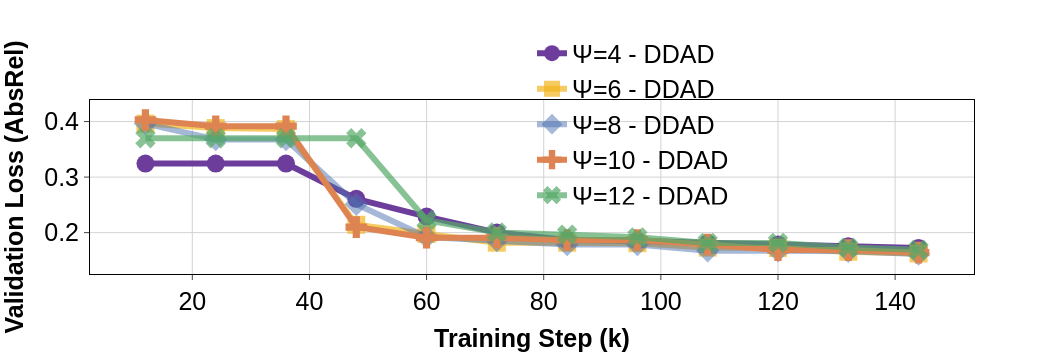

In [8]:
combined_test_loss_figures = go.Figure()
i = 0
for fig in test_loss_figures:
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_test_loss_figures.add_trace(trace)
combined_test_loss_figures.update_layout(xaxis_title="<b>Training Step (k)</b>", yaxis_title="<b>Validation Loss (AbsRel)</b>")
combined_test_loss_figures = standardize_fig(combined_test_loss_figures, **fig_config)
combined_test_loss_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0.5, y=0.4, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_test_loss_figures.show()
combined_test_loss_figures.write_image("ddad_loss_by_steps_search_range_opt.pdf")

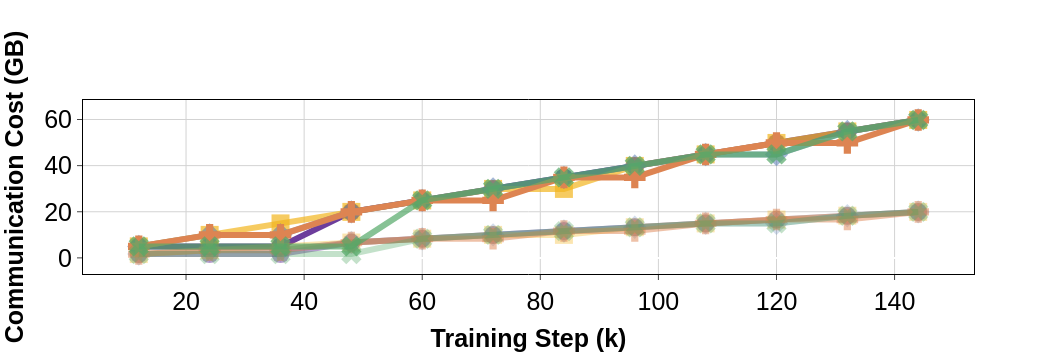

In [9]:
combined_communication_cost_figures = go.Figure()
i = 0
for j in range(len(communication_cost_upper_bound_figures)):    
    fig_upper = communication_cost_upper_bound_figures[j]
    fig_lower = communication_cost_lower_bound_figures[j]
    for k in range(len(fig_upper.data)):
        trace_upper = fig_upper.data[k]
        trace_lower = fig_lower.data[k]
        trace_upper.update(name=f"{trace_upper.name} - MAX", line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        trace_lower.update(name=f"{trace_lower.name} - MIN", line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i]*0.5)}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        combined_communication_cost_figures.add_trace(trace_upper)
        combined_communication_cost_figures.add_trace(trace_lower)
        i += 1
        
combined_communication_cost_figures.update_layout(xaxis_title="<b>Training Step (k)</b>", yaxis_title="<b>Communication Cost (GB)</b>")
combined_communication_cost_figures = standardize_fig(combined_communication_cost_figures, **fig_config)
#combined_communication_cost_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0, y=0.25, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_communication_cost_figures.update_layout(showlegend=False) 
combined_communication_cost_figures.show()
combined_communication_cost_figures.write_image("ddad_communication_cost_by_steps_search_range_opt.pdf")
combined_communication_cost_figures = go.Figure()

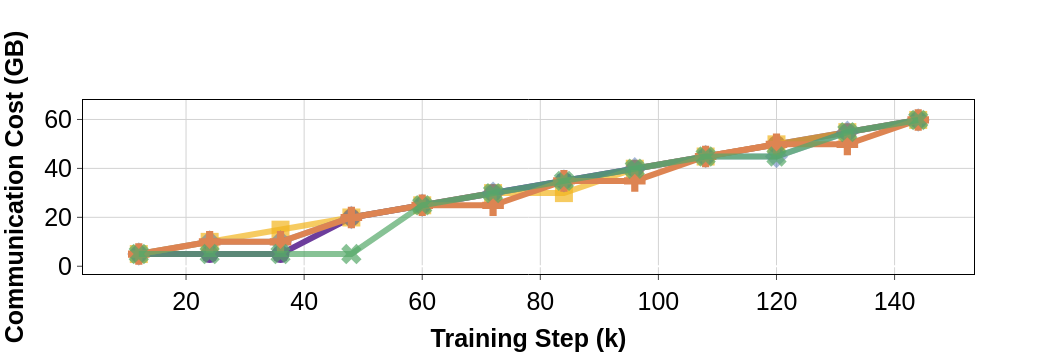

In [10]:
combined_communication_cost_upper_bound_figures = go.Figure()
i = 0
for fig in communication_cost_upper_bound_figures:    
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_communication_cost_upper_bound_figures.add_trace(trace)
combined_communication_cost_upper_bound_figures.update_layout(xaxis_title="<b>Training Step (k)</b>", yaxis_title="<b>Communication Cost (GB)</b>")
combined_communication_cost_upper_bound_figures = standardize_fig(combined_communication_cost_upper_bound_figures, **fig_config)
#combined_communication_cost_upper_bound_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0, y=0.5, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_communication_cost_upper_bound_figures.update_layout(showlegend=False) 
combined_communication_cost_upper_bound_figures.show()
combined_communication_cost_upper_bound_figures.write_image("ddad_communication_cost_upper_bound_by_steps_search_range_opt.pdf")

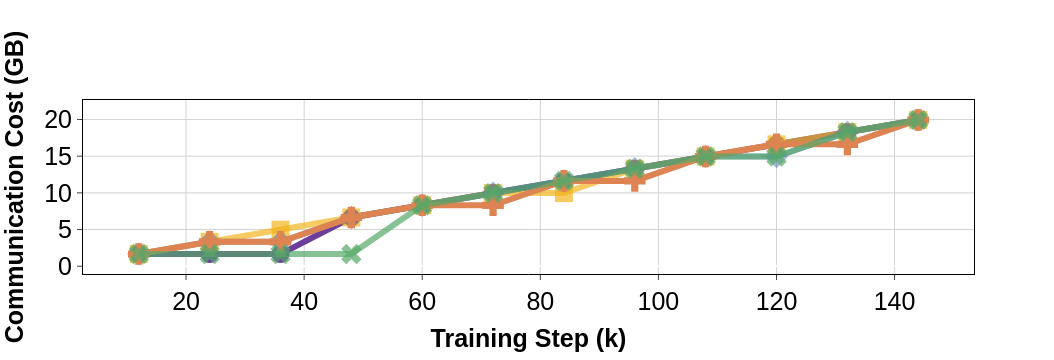

In [11]:
combined_communication_cost_lower_bound_figures = go.Figure()
i = 0
for fig in communication_cost_lower_bound_figures:    
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_communication_cost_lower_bound_figures.add_trace(trace)
combined_communication_cost_lower_bound_figures.update_layout(xaxis_title="<b>Training Step (k)</b>", yaxis_title="<b>Communication Cost (GB)</b>")
combined_communication_cost_lower_bound_figures = standardize_fig(combined_communication_cost_lower_bound_figures, **fig_config)
#combined_communication_cost_lower_bound_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0, y=0.425, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_communication_cost_lower_bound_figures.update_layout(showlegend=False) 
combined_communication_cost_lower_bound_figures.show()
combined_communication_cost_lower_bound_figures.write_image("ddad_communication_cost_lower_bound_by_steps_search_range_opt.pdf")

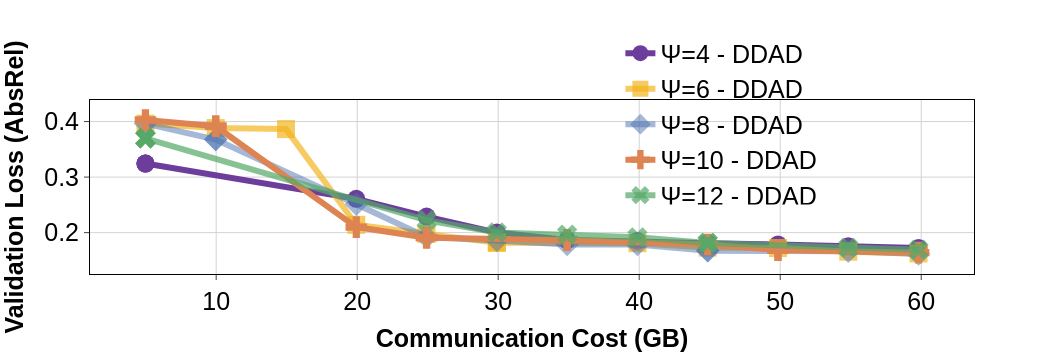

In [12]:
combined_test_loss_by_communication_cost_upper_bound_figures = go.Figure()
i = 0
for fig in test_loss_by_communication_upper_bound_cost_figures:    
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_test_loss_by_communication_cost_upper_bound_figures.add_trace(trace)
combined_test_loss_by_communication_cost_upper_bound_figures.update_layout(yaxis_title="<b>Validation Loss (AbsRel)</b>", xaxis_title="<b>Communication Cost (GB)</b>")
combined_test_loss_by_communication_cost_upper_bound_figures = standardize_fig(combined_test_loss_by_communication_cost_upper_bound_figures, **fig_config)
combined_test_loss_by_communication_cost_upper_bound_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0.6, y=0.4, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_test_loss_by_communication_cost_upper_bound_figures.show()
combined_test_loss_by_communication_cost_upper_bound_figures.write_image("ddad_loss_by_communication_cost_upper_bound_search_range_opt.pdf")

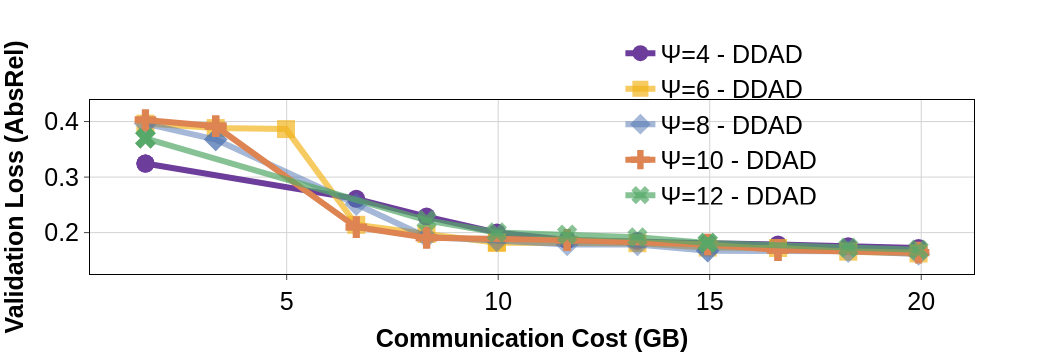

In [13]:
combined_test_loss_by_communication_cost_lower_bound_figures = go.Figure()
i = 0
for fig in test_loss_by_communication_lower_bound_cost_figures:    
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_test_loss_by_communication_cost_lower_bound_figures.add_trace(trace)
combined_test_loss_by_communication_cost_lower_bound_figures.update_layout(yaxis_title="<b>Validation Loss (AbsRel)</b>", xaxis_title="<b>Communication Cost (GB)</b>")
combined_test_loss_by_communication_cost_lower_bound_figures = standardize_fig(combined_test_loss_by_communication_cost_lower_bound_figures, **fig_config)
combined_test_loss_by_communication_cost_lower_bound_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0.6, y=0.4, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_test_loss_by_communication_cost_lower_bound_figures.show()
combined_test_loss_by_communication_cost_lower_bound_figures.write_image("ddad_loss_by_communication_cost_lower_bound_search_range_opt.pdf")

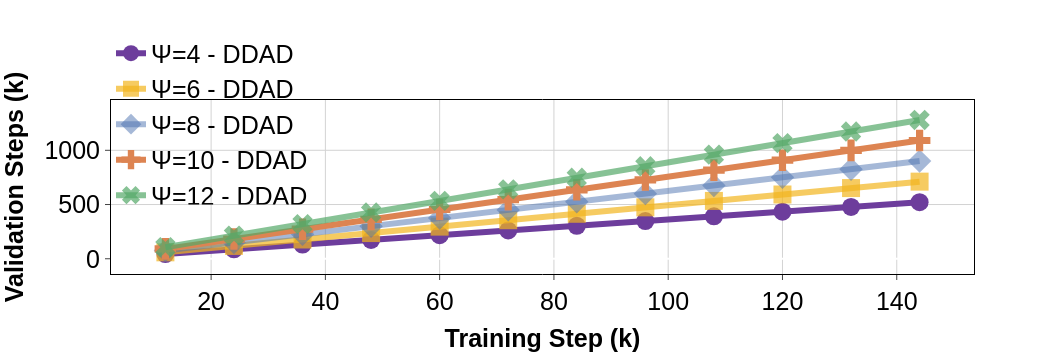

In [14]:
combined_num_inferences_figures = go.Figure()
i = 0
for fig in num_inferences_figures:
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_num_inferences_figures.add_trace(trace)
combined_num_inferences_figures.update_layout(xaxis_title="<b>Training Step (k)</b>", yaxis_title="<b>Validation Steps (k)</b>")
combined_num_inferences_figures = standardize_fig(combined_num_inferences_figures, **fig_config)
combined_num_inferences_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0, y=0.4, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_num_inferences_figures.show()
combined_num_inferences_figures.write_image("ddad_num_inferences_by_steps_search_range_opt.pdf")

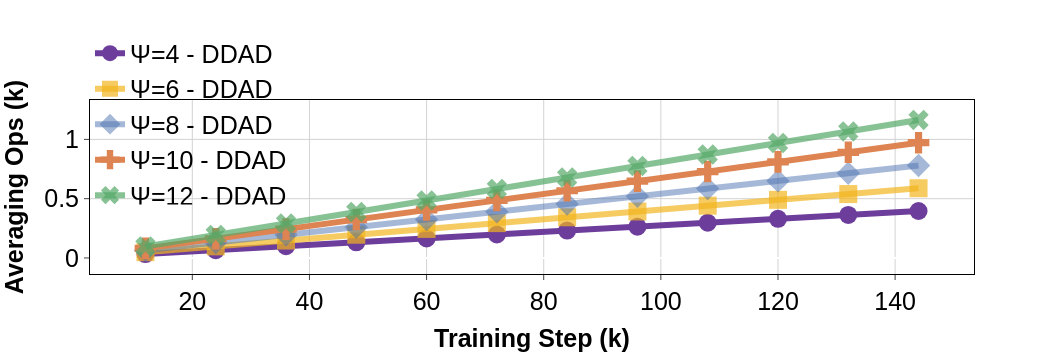

In [15]:
combined_num_averagings_figures = go.Figure()
i = 0
for fig in num_averagings_figures:
    for trace in fig.data:
        trace.update(line={'color': f'rgba{hex_to_rgba(COLORS[i], ALPHAS[i])}'}, marker=dict(symbol=MARKER_SYMBOLS[i]))
        i += 1
        combined_num_averagings_figures.add_trace(trace)
combined_num_averagings_figures.update_layout(xaxis_title="<b>Training Step (k)</b>", yaxis_title="<b>Averaging Ops (k)</b>")
combined_num_averagings_figures = standardize_fig(combined_num_averagings_figures, **fig_config)
combined_num_averagings_figures.update_layout(legend=dict(orientation="v", yanchor="bottom", x=0, y=0.4, xanchor="left", bgcolor='rgba(0,0,0,0)')) 
combined_num_averagings_figures.show()
combined_num_averagings_figures.write_image("ddad_num_averagings_by_steps_search_range_opt.pdf")